# Quantum 1BQF — short characterisation pass

Goal: **before** committing to long sweeps, find out *what costs time*
and *what looks broken*.  Everything in this notebook is sized to run
in ≲ 1–2 minutes total on CPU.

What we measure (all at small `T`, very few shots):

1. Imports + sanity (does upstream `OneBQF` even load).
2. Event-generation time vs `n_tracks`.
3. Hamiltonian construction + classical solve time.
4. OneBQF stages: `build_circuit` vs `run` vs post-select, at low shots.
5. Shot scaling at fixed `T`: success-prob and walltime.
6. `n_tracks` scaling at fixed shots: walltime + qubit count.
7. Single-event memory (`tracemalloc`).
8. cProfile of one OneBQF call → top hotspots.
9. Linear / power-law fit to extrapolate full-scale walltime.
10. Bottleneck summary + recommended next step.

The previous, much longer notebook is preserved at
[`quantum_bench_init_backup.ipynb`](quantum_bench_init_backup.ipynb).


## 1. Imports


In [1]:
from __future__ import annotations
import os, sys, time, math, json, types, logging, tracemalloc, cProfile, pstats, io
from contextlib import contextmanager
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import psutil
    _HAVE_PSUTIL = True
except ImportError:
    _HAVE_PSUTIL = False

# Stub the optional qiskit_ibm_runtime so upstream OneBQF.py imports cleanly
if "qiskit_ibm_runtime" not in sys.modules:
    _stub = types.ModuleType("qiskit_ibm_runtime")
    _stub.QiskitRuntimeService = None  # type: ignore[attr-defined]
    sys.modules["qiskit_ibm_runtime"] = _stub

ONEBQF_ROOT = Path("/data/bfys/gscriven/Quantum_Track_Reconstruction/"
                   "Toy_Characterisation/Quantum_Toy_Study/OneBQF")
if str(ONEBQF_ROOT) not in sys.path:
    sys.path.insert(0, str(ONEBQF_ROOT))

from quantum_algorithms.OneBQF import OneBQF as OneBQFRepo

from lhcb_velo_toy.generation import PlaneGeometry, StateEventGenerator
from lhcb_velo_toy.solvers import SimpleHamiltonian
from lhcb_velo_toy.solvers.classical import solve_direct

OUT = Path("/data/bfys/gscriven/Quantum_Track_Reconstruction/"
           "Toy_Characterisation/Quantum_Toy_Study/outputs/characterisation")
(OUT / "plots").mkdir(parents=True, exist_ok=True)

print("OneBQF :", OneBQFRepo.__module__, "->", sys.modules[OneBQFRepo.__module__].__file__)
print("psutil :", "yes" if _HAVE_PSUTIL else "missing (memory section will degrade)")
print("OUT    :", OUT)


OneBQF : quantum_algorithms.OneBQF -> /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Quantum_Toy_Study/OneBQF/quantum_algorithms/OneBQF.py
psutil : yes
OUT    : /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Quantum_Toy_Study/outputs/characterisation


## 2. Logging + a tiny `timed()` context

Everything in the notebook records a `(label, seconds, extra…)` row,
collected into one DataFrame so we can compare like-for-like.


In [2]:
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s [%(levelname)s] %(message)s",
                    datefmt="%H:%M:%S")
log = logging.getLogger("char")

TIMINGS: list[dict] = []

@contextmanager
def timed(label: str, **extra):
    """Time a block; records into TIMINGS and logs on exit."""
    t0 = time.perf_counter()
    err = None
    try:
        yield
    except Exception as exc:
        err = repr(exc)
        raise
    finally:
        dt = time.perf_counter() - t0
        row = {"label": label, "seconds": dt, "error": err, **extra}
        TIMINGS.append(row)
        log.info(f"{label}: {dt:.3f} s" + (f"  (ERR {err})" if err else ""))


def timings_df():
    return pd.DataFrame(TIMINGS)


print("timed() ready")


timed() ready


## 3. Tiny test sizes

Deliberately *small*.  Don't change these numbers without thinking
about the full-cost projection in §9.

| knob       | values                       | rationale                           |
|------------|------------------------------|-------------------------------------|
| `T_PROBE`  | `[1, 2, 3]`                  | enough to fit a power-law           |
| `SHOTS_*`  | `[128, 512, 2048]`           | log-spaced, lowest = sanity only    |
| reps       | 1                            | this is *characterisation*, not stats |


In [3]:
# Reference physics knobs (kept fixed for this characterisation pass)
N_MODULES   = 3
DZ_MM       = 33.0
HALF_XY_MM  = 40.0
GAMMA, DELTA = 2.0, 1.0
SCALE        = 3.0
THETA_MIN    = 1.5e-5
SIGMA_SCAT   = 2e-4
SIGMA_RES    = 1e-4

# Knobs we vary
T_PROBE      = [1, 2, 3]
SHOTS_PROBE  = [128, 512, 2048]
PROBE_T_FOR_SHOTS = 2

GEOMETRY = PlaneGeometry(
    module_id=list(range(N_MODULES)),
    lx=[HALF_XY_MM] * N_MODULES,
    ly=[HALF_XY_MM] * N_MODULES,
    z=[(i + 1) * DZ_MM for i in range(N_MODULES)],
)
print(f"T_PROBE={T_PROBE}  SHOTS_PROBE={SHOTS_PROBE}  T@shots-scan={PROBE_T_FOR_SHOTS}")


T_PROBE=[1, 2, 3]  SHOTS_PROBE=[128, 512, 2048]  T@shots-scan=2


## 4. Benchmark event generation

How long does it take to generate one event of `T` tracks?
This is *not* the bottleneck (we expect ms), but we record it so we can
subtract it from the OneBQF totals later.


In [4]:
def make_event(n_tracks: int, seed: int = 42):
    np.random.seed(seed + n_tracks)
    spec = [[{"type": "pion", "mass": 139.6, "q": 1}] * n_tracks]
    gen = StateEventGenerator(
        detector_geometry=GEOMETRY, events=1, n_particles=[n_tracks],
        phi_min=-0.2, phi_max=0.2, theta_min=-0.2, theta_max=0.2,
        measurement_error=SIGMA_RES, collision_noise=SIGMA_SCAT,
    )
    gen.generate_random_primary_vertices({"x": 0.0, "y": 0.0, "z": 1.0})
    gen.generate_particles(spec)
    ev = gen.generate_complete_events()
    return ev, gen


events_cache: dict[int, tuple] = {}
for T in T_PROBE:
    with timed("event_gen", T=T):
        events_cache[T] = make_event(T)
    ev, _ = events_cache[T]
    log.info(f"  T={T}: {len(ev.tracks)} truth tracks, {len(ev.hits)} hits")


14:06:20 [INFO] event_gen: 0.001 s
14:06:20 [INFO]   T=1: 1 truth tracks, 3 hits
14:06:20 [INFO] event_gen: 0.000 s
14:06:20 [INFO]   T=2: 2 truth tracks, 6 hits
14:06:20 [INFO] event_gen: 0.000 s
14:06:20 [INFO]   T=3: 3 truth tracks, 9 hits


## 5. Core computation on a tiny sample

For each `T ∈ T_PROBE`:

1. Build `A, b` (`SimpleHamiltonian.construct_hamiltonian`).
2. Classical solve via `solve_direct`.
3. **OneBQF** — broken into the four stages that actually consume time:
   - construct (numpy / linear algebra inside `__init__`)
   - `build_circuit`
   - `run` (`AerSimulator`)
   - post-select counts → solution.

The point is to see *which stage dominates* before we scale anything.
Shots are deliberately low (`SHOTS_PROBE[0]`).


In [5]:
def compute_epsilon(sigma_scatter, sigma_res,
                    dz=DZ_MM, scale=SCALE, theta_min=THETA_MIN):
    theta_s = scale * sigma_scatter
    theta_r = math.atan((scale * sigma_res) / dz)
    return math.sqrt(2 * theta_s ** 2 + 12 * theta_r ** 2 + 2 * theta_min ** 2)


def build_hamiltonian(gen):
    eps = compute_epsilon(SIGMA_SCAT, SIGMA_RES)
    ham = SimpleHamiltonian(epsilon=eps, gamma=GAMMA, delta=DELTA)
    A, b = ham.construct_hamiltonian(gen, convolution=False)
    return A, b, ham, eps


def post_select(counts: dict, n_qsys: int):
    """Mirror upstream OneBQF post-selection.  Upstream `get_solution`
    is broken (no return); we reproduce it inline."""
    prob = np.zeros(2 ** n_qsys)
    n_succ = 0
    n_total = 0
    for outcome, c in counts.items():
        bits = outcome.replace(" ", "")
        n_total += c
        if bits[-1] != "1":
            continue
        prob[int(bits[:-1], 2)] += c
        n_succ += c
    if n_succ == 0:
        return np.zeros(2 ** n_qsys), 0.0
    prob /= prob.sum()
    sol = np.sqrt(prob)
    sol /= np.linalg.norm(sol)
    return sol, n_succ / n_total


SHOTS_TINY = SHOTS_PROBE[0]
core_records: list[dict] = []

for T in T_PROBE:
    ev, gen = events_cache[T]

    with timed("hamiltonian", T=T):
        A, b, ham, eps = build_hamiltonian(gen)
    n_seg = ham.n_segments
    n_qsys = int(math.ceil(math.log2(max(n_seg, 2))))

    A_d = A.toarray() if hasattr(A, "toarray") else np.asarray(A, dtype=float)
    b_d = np.asarray(b, dtype=float).ravel()
    log.info(f"T={T}: n_seg={n_seg}, n_qsys={n_qsys}, "
             f"||A||_F={np.linalg.norm(A_d):.3g}, "
             f"cond≈{np.linalg.cond(A_d):.3g}")

    with timed("classical_solve", T=T, n_seg=n_seg):
        x_C = np.asarray(solve_direct(A, b)).ravel()

    # OneBQF broken into stages (shots = SHOTS_TINY for sanity)
    with timed("obqf_init", T=T, n_seg=n_seg, shots=SHOTS_TINY):
        obqf = OneBQFRepo(A_d, b_d, num_time_qubits=1, shots=SHOTS_TINY)

    with timed("obqf_build_circuit", T=T, n_seg=n_seg):
        obqf.build_circuit()
    n_qubits = obqf.circuit.num_qubits
    depth    = obqf.circuit.depth()
    n_gates  = sum(obqf.circuit.count_ops().values())

    with timed("obqf_run", T=T, n_seg=n_seg, shots=SHOTS_TINY):
        counts = obqf.run(use_noise_model=False)

    with timed("obqf_postselect", T=T, n_seg=n_seg):
        sol_padded, p_succ = post_select(counts, obqf.num_system_qubits)
    sol_Q = sol_padded[: A_d.shape[0]]

    # Sign-blind cosine of |x|
    nC = np.linalg.norm(x_C); nQ = np.linalg.norm(sol_Q)
    cos_abs = float(abs(np.dot(np.abs(x_C) / max(nC, 1e-12),
                                np.abs(sol_Q) / max(nQ, 1e-12))))

    core_records.append({
        "T": T, "n_seg": n_seg, "n_qubits": n_qubits,
        "depth": depth, "n_gates": n_gates,
        "cond_A": float(np.linalg.cond(A_d)),
        "p_succ": p_succ, "cos_abs": cos_abs,
        "shots": SHOTS_TINY,
    })

core_df = pd.DataFrame(core_records)
core_df


14:06:24 [INFO] hamiltonian: 0.002 s
14:06:24 [INFO] T=1: n_seg=2, n_qsys=1, ||A||_F=4.47, cond≈2
14:06:24 [INFO] classical_solve: 0.001 s
14:06:24 [INFO] obqf_init: 0.000 s
14:06:24 [INFO] obqf_build_circuit: 0.002 s
14:06:24 [INFO] Pass: ContainsInstruction - 0.01621 (ms)
14:06:24 [INFO] Pass: UnitarySynthesis - 0.01144 (ms)
14:06:24 [INFO] Pass: HighLevelSynthesis - 0.00930 (ms)
14:06:24 [INFO] Pass: BasisTranslator - 0.08082 (ms)
14:06:24 [INFO] Pass: ElidePermutations - 0.01335 (ms)
14:06:24 [INFO] Pass: RemoveDiagonalGatesBeforeMeasure - 0.00954 (ms)
14:06:24 [INFO] Pass: RemoveIdentityEquivalent - 0.03362 (ms)
14:06:24 [INFO] Pass: InverseCancellation - 0.02193 (ms)
14:06:24 [INFO] Pass: ContractIdleWiresInControlFlow - 0.00453 (ms)
14:06:24 [INFO] Pass: CommutativeCancellation - 0.05031 (ms)
14:06:24 [INFO] Pass: ConsolidateBlocks - 0.73385 (ms)
14:06:24 [INFO] Pass: Split2QUnitaries - 0.00501 (ms)
14:06:24 [INFO] Pass: UnitarySynthesis - 0.00930 (ms)
14:06:24 [INFO] Pass: High

,T,n_seg,n_qubits,depth,n_gates,cond_A,p_succ,cos_abs,shots
0,1,2,3,11,14,2.0,0.250000,0.995556,128
1,2,8,5,16,28,2.0,0.179688,0.816952,128
2,3,18,7,37,82,2.0,0.070312,0.582040,128


## 6. Memory profile (`tracemalloc` + RSS)

Single OneBQF call at `T = max(T_PROBE)` and the lowest shot count.
Reports:
- peak Python-allocator memory while running (`tracemalloc`)
- resident set size delta (`psutil`, if available).


In [6]:
T_MEM = max(T_PROBE)
ev, gen = events_cache[T_MEM]
A, b, ham, _ = build_hamiltonian(gen)
A_d = A.toarray() if hasattr(A, "toarray") else np.asarray(A, dtype=float)
b_d = np.asarray(b, dtype=float).ravel()

rss_before = psutil.Process().memory_info().rss / 1e6 if _HAVE_PSUTIL else None
tracemalloc.start()
with timed("obqf_full_for_memory", T=T_MEM, shots=SHOTS_TINY):
    o = OneBQFRepo(A_d, b_d, num_time_qubits=1, shots=SHOTS_TINY)
    o.build_circuit()
    counts = o.run(use_noise_model=False)
    _ = post_select(counts, o.num_system_qubits)
peak_alloc = tracemalloc.get_traced_memory()[1] / 1e6
tracemalloc.stop()
rss_after = psutil.Process().memory_info().rss / 1e6 if _HAVE_PSUTIL else None

print(f"T={T_MEM} shots={SHOTS_TINY}")
print(f"  tracemalloc peak: {peak_alloc:7.1f} MB")
if rss_before is not None:
    print(f"  RSS Δ            : {rss_after - rss_before:+7.1f} MB  "
          f"({rss_before:.1f} → {rss_after:.1f})")


14:06:32 [INFO] Pass: ContainsInstruction - 0.02861 (ms)
14:06:32 [INFO] Pass: UnitarySynthesis - 0.01955 (ms)
14:06:32 [INFO] Pass: HighLevelSynthesis - 0.47421 (ms)
14:06:32 [INFO] Pass: BasisTranslator - 0.16761 (ms)
14:06:32 [INFO] Pass: ElidePermutations - 0.01097 (ms)
14:06:32 [INFO] Pass: RemoveDiagonalGatesBeforeMeasure - 0.02241 (ms)
14:06:32 [INFO] Pass: RemoveIdentityEquivalent - 0.09322 (ms)
14:06:32 [INFO] Pass: InverseCancellation - 0.28133 (ms)
14:06:32 [INFO] Pass: ContractIdleWiresInControlFlow - 0.00691 (ms)
14:06:32 [INFO] Pass: CommutativeCancellation - 0.97871 (ms)
14:06:32 [INFO] Pass: ConsolidateBlocks - 3.53432 (ms)
14:06:32 [INFO] Pass: Split2QUnitaries - 0.01025 (ms)
14:06:32 [INFO] Pass: UnitarySynthesis - 0.02098 (ms)
14:06:32 [INFO] Pass: HighLevelSynthesis - 0.51999 (ms)
14:06:32 [INFO] Pass: BasisTranslator - 0.24438 (ms)
14:06:32 [INFO] Pass: Depth - 0.08845 (ms)
14:06:32 [INFO] Pass: Size - 0.01264 (ms)
14:06:32 [INFO] Pass: MinimumPoint - 0.02909 (ms)


T=3 shots=128
  tracemalloc peak:     0.4 MB
  RSS Δ            :    +1.3 MB  (209.1 → 210.4)


## 7. CPU hotspots (`cProfile`)

One OneBQF call at `T = max(T_PROBE)`, sorted by cumulative time.
Top 20 only — this is where the real time is spent.


In [7]:
def _one_obqf(A_d, b_d, shots):
    o = OneBQFRepo(A_d, b_d, num_time_qubits=1, shots=shots)
    o.build_circuit()
    counts = o.run(use_noise_model=False)
    return post_select(counts, o.num_system_qubits)


pr = cProfile.Profile()
with timed("obqf_full_profiled", T=T_MEM, shots=SHOTS_TINY):
    pr.enable()
    _one_obqf(A_d, b_d, SHOTS_TINY)
    pr.disable()

buf = io.StringIO()
pstats.Stats(pr, stream=buf).strip_dirs().sort_stats("cumulative").print_stats(20)
hotspots = buf.getvalue()
print(hotspots)
(OUT / "cprofile_top20.txt").write_text(hotspots)


14:06:36 [INFO] Pass: ContainsInstruction - 0.02027 (ms)
14:06:36 [INFO] Pass: UnitarySynthesis - 0.02980 (ms)
14:06:36 [INFO] Pass: HighLevelSynthesis - 0.40245 (ms)
14:06:36 [INFO] Pass: BasisTranslator - 0.08130 (ms)
14:06:36 [INFO] Pass: ElidePermutations - 0.01621 (ms)
14:06:36 [INFO] Pass: RemoveDiagonalGatesBeforeMeasure - 0.02551 (ms)
14:06:36 [INFO] Pass: RemoveIdentityEquivalent - 0.08512 (ms)
14:06:36 [INFO] Pass: InverseCancellation - 0.27061 (ms)
14:06:36 [INFO] Pass: ContractIdleWiresInControlFlow - 0.01121 (ms)
14:06:36 [INFO] Pass: CommutativeCancellation - 0.92173 (ms)
14:06:36 [INFO] Pass: ConsolidateBlocks - 2.85053 (ms)
14:06:36 [INFO] Pass: Split2QUnitaries - 0.01240 (ms)
14:06:36 [INFO] Pass: UnitarySynthesis - 0.01669 (ms)
14:06:36 [INFO] Pass: HighLevelSynthesis - 0.48089 (ms)
14:06:36 [INFO] Pass: BasisTranslator - 0.16141 (ms)
14:06:36 [INFO] Pass: Depth - 0.08178 (ms)
14:06:36 [INFO] Pass: Size - 0.01144 (ms)
14:06:36 [INFO] Pass: MinimumPoint - 0.02575 (ms)


         319823 function calls (318355 primitive calls) in 0.371 seconds

   Ordered by: cumulative time
   List reduced from 858 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
       11    0.004    0.000    1.537    0.140 aer_compiler.py:875(_assemble_op)
        1    0.000    0.000    0.266    0.266 generate_preset_pass_manager.py:40(generate_preset_pass_manager)
      158    0.026    0.000    0.246    0.002 aerbackend.py:237(target)
        1    0.004    0.004    0.241    0.241 generate_preset_pass_manager.py:323(_parse_basis_gates)
      161    0.001    0.000    0.173    0.001 base_events.py:1922(_run_once)
      162    0.001    0.000    0.113    0.001 events.py:86(_run)
    15484    0.026    0.000    0.111    0.000 target.py:356(add_instruction)
      162    0.000    0.000    0.099    0.001 {method 'run' of '_contextvars.Context' objects}
      158    0.000    0.000    0.096    0.001 ioloop.py:750(_run_callback)
      159    

1839

## 8. I/O probe

Round-trip a representative array (`A` for `T = max(T_PROBE)`) through
disk to flag any pathological I/O before we start dumping per-event
pickles in a long sweep.


In [8]:
io_path = OUT / "io_probe.npz"
with timed("io_write", bytes=A_d.nbytes + b_d.nbytes):
    np.savez(io_path, A=A_d, b=b_d)
with timed("io_read"):
    z = np.load(io_path)
    _ = z["A"], z["b"]
print(f"file size: {io_path.stat().st_size / 1024:.1f} KiB")


14:06:41 [INFO] io_write: 0.002 s
14:06:41 [INFO] io_read: 0.002 s


file size: 3.2 KiB


## 9. Scaling probes

Two cheap one-dimensional sweeps:

- **Shots** at fixed `T = PROBE_T_FOR_SHOTS`. Expectation: `obqf_run`
  scales roughly linearly in shots; `build_circuit` is shot-independent.
- **`n_tracks`** at fixed shots = `SHOTS_TINY`. Expectation: walltime
  grows fast with `n_qubits = ⌈log2 n_seg⌉ + 1` (the `Aer` simulator
  uses dense statevectors).

We then fit a power law to walltime-vs-`n_seg` and extrapolate to a
"full-scale" target the user can change.


In [9]:
# ---- shot scan at fixed T ------------------------------------------------
ev_s, gen_s = events_cache[PROBE_T_FOR_SHOTS]
A_s, b_s, ham_s, _ = build_hamiltonian(gen_s)
A_s_d = A_s.toarray() if hasattr(A_s, "toarray") else np.asarray(A_s)
b_s_d = np.asarray(b_s).ravel()

shot_rows = []
for s in SHOTS_PROBE:
    o = OneBQFRepo(A_s_d, b_s_d, num_time_qubits=1, shots=s)
    with timed("shot_scan_build", T=PROBE_T_FOR_SHOTS, shots=s):
        o.build_circuit()
    t0 = time.perf_counter()
    counts = o.run(use_noise_model=False)
    t_run = time.perf_counter() - t0
    _, p_succ = post_select(counts, o.num_system_qubits)
    shot_rows.append({"shots": s, "t_run": t_run, "p_succ": p_succ})
shot_df = pd.DataFrame(shot_rows)
print(shot_df)


14:06:44 [INFO] shot_scan_build: 0.004 s
14:06:44 [INFO] Pass: ContainsInstruction - 0.01550 (ms)
14:06:44 [INFO] Pass: UnitarySynthesis - 0.01335 (ms)
14:06:44 [INFO] Pass: HighLevelSynthesis - 0.15306 (ms)
14:06:44 [INFO] Pass: BasisTranslator - 0.06866 (ms)
14:06:44 [INFO] Pass: ElidePermutations - 0.00882 (ms)
14:06:44 [INFO] Pass: RemoveDiagonalGatesBeforeMeasure - 0.01192 (ms)
14:06:44 [INFO] Pass: RemoveIdentityEquivalent - 0.04053 (ms)
14:06:44 [INFO] Pass: InverseCancellation - 0.05102 (ms)
14:06:44 [INFO] Pass: ContractIdleWiresInControlFlow - 0.00620 (ms)
14:06:44 [INFO] Pass: CommutativeCancellation - 0.09751 (ms)
14:06:44 [INFO] Pass: ConsolidateBlocks - 1.11413 (ms)
14:06:44 [INFO] Pass: Split2QUnitaries - 0.00739 (ms)
14:06:44 [INFO] Pass: UnitarySynthesis - 0.01001 (ms)
14:06:44 [INFO] Pass: HighLevelSynthesis - 0.19145 (ms)
14:06:44 [INFO] Pass: BasisTranslator - 0.09060 (ms)
14:06:44 [INFO] Pass: Depth - 0.02360 (ms)
14:06:44 [INFO] Pass: Size - 0.00548 (ms)
14:06:44 

   shots     t_run    p_succ
0    128  0.174677  0.093750
1    512  0.172403  0.150391
2   2048  0.172635  0.136719


In [10]:
# ---- power-law fit: total OneBQF walltime vs n_seg -----------------------
df = timings_df()
stage_obqf = df[df["label"].isin(["obqf_init", "obqf_build_circuit",
                                  "obqf_run", "obqf_postselect"])]
total = stage_obqf.groupby("T").agg(t_obqf=("seconds", "sum"),
                                    n_seg=("n_seg", "max")).reset_index()
print("Per-T totals:\n", total)

# Fit log(t) = a + b * log(n_seg) on the points we have
EXTRAP_T  = [3, 4, 5, 6, 7, 8, 9, 10]   # change this to whatever you want to project
fit_ok = total["n_seg"].nunique() >= 2 and (total["t_obqf"] > 0).all()
if fit_ok:
    lx = np.log(total["n_seg"].to_numpy(float))
    ly = np.log(total["t_obqf"].to_numpy(float))
    b_, a_ = np.polyfit(lx, ly, 1)
    print(f"\nfit: t = {math.exp(a_):.3g} · n_seg^{b_:.2f}  "
          f"(R²={1 - np.var(ly - (a_ + b_*lx))/np.var(ly):.3f})")
else:
    a_ = b_ = None
    print("Not enough points to fit a power law.")

# Project onto unseen T (assumes n_seg(T) follows the same family of geometries)
proj_rows = []
for T in EXTRAP_T:
    # quick estimate: build A,b for this T (cheap) — only if not already cached
    if T not in events_cache:
        events_cache[T] = make_event(T)
    _, gen_T = events_cache[T]
    A_T, _, ham_T, _ = build_hamiltonian(gen_T)
    n_seg_T = ham_T.n_segments
    n_q_T = int(math.ceil(math.log2(max(n_seg_T, 2)))) + 1
    if a_ is not None:
        t_proj = math.exp(a_ + b_ * math.log(n_seg_T))
    else:
        t_proj = float("nan")
    proj_rows.append({"T": T, "n_seg": n_seg_T,
                      "n_qubits": n_q_T, "t_proj_s": t_proj})
proj_df = pd.DataFrame(proj_rows)
print("\nExtrapolation (single OneBQF call, no overhead):")
print(proj_df.to_string(index=False))


Per-T totals:
      T    t_obqf  n_seg
0  1.0  0.213979    2.0
1  2.0  0.177676    8.0
2  3.0  0.205306   18.0

fit: t = 0.21 · n_seg^-0.03  (R²=0.126)

Extrapolation (single OneBQF call, no overhead):
 T  n_seg  n_qubits  t_proj_s
 3     18         6  0.192247
 4     32         6  0.188822
 5     50         7  0.186207
 6     72         8  0.184098
 7     98         8  0.182333
 8    128         8  0.180818
 9    162         9  0.179492
10    200         9  0.178314


## 10. Bottleneck summary

Stage breakdown (mean over the `T_PROBE` events) and the headline
projection from §9 to inform what scale of run is sensible next.


Stage timings (s):
                    mean_s   max_s  n
label                                
obqf_run            0.1944  0.2116  3
obqf_build_circuit  0.0042  0.0068  3
io_read             0.0025  0.0025  1
io_write            0.0017  0.0017  1
hamiltonian         0.0013  0.0016  3
classical_solve     0.0006  0.0006  3
event_gen           0.0004  0.0005  3
obqf_init           0.0003  0.0005  3
obqf_postselect     0.0001  0.0001  3


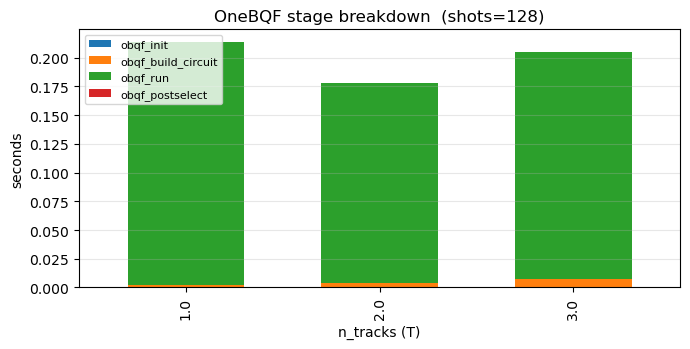


Headline:
  Slowest single stage : obqf_run (mean 0.194 s)
  Power-law fit        : t ∝ n_seg^-0.03
  Projected wall at T=10 (n_seg=200, 9 qubits): 0.2 s/event at 128 shots.

See timings.csv and cprofile_top20.txt in: /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Quantum_Toy_Study/outputs/characterisation


In [11]:
df = timings_df()
df.to_csv(OUT / "timings.csv", index=False)

stages = ["event_gen", "hamiltonian", "classical_solve",
          "obqf_init", "obqf_build_circuit", "obqf_run", "obqf_postselect",
          "io_write", "io_read"]
stage_summary = (df[df["label"].isin(stages)]
                 .groupby("label")
                 .agg(mean_s=("seconds", "mean"),
                      max_s =("seconds", "max"),
                      n     =("seconds", "count"))
                 .reindex(stages)
                 .dropna()
                 .sort_values("mean_s", ascending=False))
print("Stage timings (s):")
print(stage_summary.round(4).to_string())

# Stacked-bar of per-T OneBQF stages
obqf_stages = ["obqf_init", "obqf_build_circuit", "obqf_run", "obqf_postselect"]
piv = (df[df["label"].isin(obqf_stages)]
       .pivot_table(index="T", columns="label", values="seconds", aggfunc="sum")
       .reindex(columns=obqf_stages))
fig, ax = plt.subplots(figsize=(7, 3.6))
piv.plot(kind="bar", stacked=True, ax=ax, width=0.6)
ax.set_xlabel("n_tracks (T)")
ax.set_ylabel("seconds")
ax.set_title(f"OneBQF stage breakdown  (shots={SHOTS_TINY})")
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig(OUT / "plots" / "obqf_stage_breakdown.png", dpi=140)
plt.show()

# Headline message
big = stage_summary.head(1)
print("\nHeadline:")
print(f"  Slowest single stage : {big.index[0]} "
      f"(mean {big['mean_s'].iloc[0]:.3f} s)")
if a_ is not None:
    print(f"  Power-law fit        : t ∝ n_seg^{b_:.2f}")
    big_T = proj_df.iloc[-1]
    print(f"  Projected wall at T={int(big_T['T'])} (n_seg={int(big_T['n_seg'])}, "
          f"{int(big_T['n_qubits'])} qubits): {big_T['t_proj_s']:.1f} s/event "
          f"at {SHOTS_TINY} shots.")
print("\nSee timings.csv and cprofile_top20.txt in:", OUT)
